# N26 — 用戶收支預測（GAMMA_DNA 解法）

**任務（N26 Assignment）**：依 ~10k 用戶的交易紀錄與人口統計 profile，建立 **regression** 模型分別預測 **total income** 與 **total expenses**。

**限制**：本 notebook **僅使用 `gamma` 套件的 `GAMMA_DNA`（v2）**，不使用 legacy `GAMMA_DNA_v1`。

**資料**（`datasets 2/`）：

| 檔案 | 說明 |
|------|------|
| `transactions_data_training.csv` | 交易明細（~408k 筆） |
| `user_profile.csv` | 用戶 demographics |
| `transaction_types.csv` | 交易類型與 In/Out 方向 |
| `mcc_group_definition.csv` | 商戶類別字典 |

| 區塊 | GAMMA_DNA API |
|------|---------------|
| 載入 | `gamma_de_load_files` |
| 特徵工程 | `g.pipe().run()` — 交易彙總 + profile merge |
| EDA | `g.skim`, `g.eda`, `g.viz.*`, `g.correlation_heatmap`, `g.leakage` |
| 前處理 | `g.clean()` |
| 切分 | `g.train(test_size=0.2, random_state=42)` |
| 多模型 | `g.train` × N + `g.experiment.compare()` / `g.compare_models()` |
| 評估 | `ModelResult.summary()`, `plot()`, `g.explain()` |


## 0. 環境設定


In [ ]:
import sys
import os
from pathlib import Path

# Resolve GAMMA_ROOT relative to notebook location (analytics-gym/N2O → analytics-gym → DAPS_Brix)
GAMMA_ROOT = Path(os.getcwd()).parent.parent
if not (GAMMA_ROOT / "gamma").exists():
    _p = Path(os.getcwd())
    while _p != _p.parent:
        if (_p / "gamma").exists():
            GAMMA_ROOT = _p
            break
        _p = _p.parent

if str(GAMMA_ROOT) not in sys.path:
    sys.path.insert(0, str(GAMMA_ROOT))

from gamma import GAMMA_DNA
from gamma.data_exploration import gamma_de_load_files
from gamma.qb_theme import apply_qb_theme
from IPython.display import display

apply_qb_theme()

DATA_DIR = Path("datasets 2")
RANDOM_STATE = 42
TEST_SIZE = 0.2

## 1. 載入資料

使用 `gamma_de_load_files` 一次載入目錄內所有 CSV；交易方向對照 `transaction_types.csv` 的 `direction` 欄（`In` → income、`Out` → expense）。


In [11]:
files = gamma_de_load_files(str(DATA_DIR.resolve()))
# gamma_de_load_files 目錄模式：dict key 為檔名 stem（不含 .csv）
print("Loaded keys:", sorted(files.keys()))
for name, df in sorted(files.items()):
    print(f"  {name}: {len(df):,} rows × {df.shape[1]} cols")


Loaded keys: ['mcc_group_definition', 'transaction_types', 'transactions_data_training', 'user_profile']
  mcc_group_definition: 17 rows × 2 cols
  transaction_types: 23 rows × 4 cols
  transactions_data_training: 408,546 rows × 7 cols
  user_profile: 9,470 rows × 9 cols


## 2. 用戶層級特徵表（`g.pipe`）

**設計決策**

1. **目標變數**：依交易方向加總 `amount_n26_currency` → `total_income` / `total_expenses`。
2. **特徵**：profile demographics + 交易行為摘要（筆數、活躍天數、平均金額等），**不含**另一個目標欄位以避免 label leakage。
3. **Join**：`inner` merge profile 與有交易的用戶。
4. **排除 `user_id`**：高基數 ID，不作為模型特徵。


In [12]:
import pandas as pd

profile = files["user_profile"].copy()
profile["total_income"] = 0.0
profile["total_expenses"] = 0.0

g = GAMMA_DNA(profile, target="total_income", task="regression", name="n26_build")

TX = files["transactions_data_training"]
TYPES = files["transaction_types"]
DIR_MAP = TYPES.set_index("type")["direction"]


def build_user_master(df_profile):
    tx = TX.copy()
    tx["direction"] = tx["transaction_type"].map(DIR_MAP)
    tx["amount_n26_currency"] = pd.to_numeric(tx["amount_n26_currency"], errors="coerce")
    tx["transaction_date"] = pd.to_datetime(tx["transaction_date"], errors="coerce")

    in_sum = (
        tx.loc[tx["direction"] == "In"]
        .groupby("user_id")["amount_n26_currency"]
        .sum()
        .rename("total_income")
    )
    out_sum = (
        tx.loc[tx["direction"] == "Out"]
        .groupby("user_id")["amount_n26_currency"]
        .sum()
        .rename("total_expenses")
    )

    agg = tx.groupby("user_id").agg(
        txn_count=("amount_n26_currency", "count"),
        in_count=("direction", lambda s: (s == "In").sum()),
        out_count=("direction", lambda s: (s == "Out").sum()),
        active_days=("transaction_date", lambda s: s.dt.date.nunique()),
        avg_amount=("amount_n26_currency", "mean"),
        std_amount=("amount_n26_currency", "std"),
    )

    user = df_profile.drop(columns=["total_income", "total_expenses"], errors="ignore")
    user = user.merge(agg, on="user_id", how="inner")
    user = user.merge(in_sum, on="user_id", how="left")
    user = user.merge(out_sum, on="user_id", how="left")
    user[["total_income", "total_expenses"]] = user[["total_income", "total_expenses"]].fillna(0.0)
    return user


g.pipe("user_master", build_user_master).run(from_stage="raw")
user_master = g.get("user_master")
print(f"User-level rows: {len(user_master):,}")
print(
    user_master[["total_income", "total_expenses"]]
    .describe()
    .loc[["mean", "50%", "max"]]
    .rename(index={"50%": "median"})
)


User-level rows: 9,470
        total_income  total_expenses
mean     1049.178986     1210.547307
median    516.000000      526.000000
max     24651.000000    26195.000000


## 3. 探索性分析（EDA）

以 **total income** 為探索目標；觀察 demographics 與交易強度特徵的分布與相關性。


In [13]:
g_income = GAMMA_DNA(user_master, target="total_income", task="regression", name="n26_income")
print(f"Rows={len(g_income.df):,}  task={g_income.task}")
g_income.skim()


Rows=9,470  task=regression


,variable,dtype,n,n_missing,pct_missing,n_unique,top,top_freq,mean,std,se,min,p25,median,p75,max,skew,kurtosis
0,user_id,object,9470,0,0.0,9470,000295594379774ab9ac2c78c946d615,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,age,int64,9470,0,0.0,47,NaN,NaN,43.3646,9.3149,0.0957,21.0,37.000000,43.000000,50.000000,67.000000,-0.0480,-0.6514
2,age_band,object,9470,0,0.0,5,35-44,3469.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,country,object,9470,0,0.0,5,DE,5158.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,city_tier,int64,9470,0,0.0,3,NaN,NaN,2.0049,0.6295,0.0065,1.0,2.000000,2.000000,2.000000,3.000000,-0.0037,-0.4760
5,employment_status,object,9470,0,0.0,6,employed_ft,4462.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,industry,object,9470,0,0.0,9,other,3172.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,income_band,object,9470,0,0.0,6,30-50k,4103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,account_tenure_days,int64,9470,0,0.0,127,NaN,NaN,129.5961,27.0056,0.2775,66.0,109.000000,130.000000,151.000000,194.000000,-0.0292,-0.8168
9,txn_count,int64,9470,0,0.0,273,NaN,NaN,42.8714,47.1640,0.4847,1.0,9.000000,26.000000,60.000000,483.000000,2.0304,5.9201


In [14]:
eda = g_income.eda(segment_cols=["country", "employment_status"])
eda.summary()
display(eda.top_signals())


🔍 Running EDA pipeline...
  [1/5] Inspecting structure...
  [2/5] Inspecting quality...
  [3/5] Analysing missingness...
  [4/5] Analysing feature → 'total_income' relationships...
  [5/5] Analysing redundancy...
✅ EDA complete.


  Structure Report
  Rows              : 9,470
  Columns           : 17
  Memory            : 4.45 MB

  Numeric           : 11 cols  ['age', 'city_tier', 'account_tenure_days', 'txn_count', 'in_count', 'out_count']...
  Categorical       : 5 cols  ['age_band', 'country', 'employment_status', 'industry', 'income_band']
  Text              : 1 cols  ['user_id']
  ⚠ Potential IDs   : ['user_id', 'std_amount']
  ⚠ Num-as-cat?     : ['city_tier']

  Warnings:
    • Potential ID columns (consider excluding from analysis): ['user_id', 'std_amount']

  Data Quality Report
  Duplicate rows     : 0
  Cols with missing  : 1
    std_amount                     3.6%
  Outlier candidates : ['txn_count', 'in_count', 'out_count', 'avg_amount', 'std_amount']

  Warnings:
    

,feature,signal_score,relationship_strength,monotonicity_score,lift_max,interpretation
0,total_expenses,89.91,0.9142,1.000,3.687,Feature `total_expenses` shows a strong positi...
1,txn_count,82.17,0.7435,1.000,3.422,Feature `txn_count` shows a strong positive mo...
2,active_days,81.43,0.7300,1.000,3.382,Feature `active_days` shows a strong positive ...
3,in_count,80.92,0.7871,1.000,3.006,Feature `in_count` shows a strong positive mon...
4,out_count,80.31,0.7119,1.000,3.309,Feature `out_count` shows a strong positive mo...
5,std_amount,69.74,0.5576,1.000,2.587,Feature `std_amount` shows a strong positive m...
6,avg_amount,58.60,0.3527,1.000,1.939,Feature `avg_amount` shows a strong positive m...
7,age,52.40,0.3351,0.889,1.933,Feature `age` shows a strong positive monotoni...
8,city_tier,50.43,0.2694,1.000,1.150,Feature `city_tier` shows a moderate negative ...
9,account_tenure_days,41.03,0.2226,0.778,1.651,Feature `account_tenure_days` shows a moderate...


In [15]:
g_income.use("raw")
g_income.viz.scatter("txn_count", "total_income")
g_income.viz.scatter("account_tenure_days", "total_income")
g_income.correlation_heatmap()


total_expenses         0.749114
txn_count              0.743531
active_days            0.729989
out_count              0.711937
in_count               0.561370
std_amount             0.557572
age                    0.335106
avg_amount             0.302039
account_tenure_days    0.222633
city_tier             -0.269400
Name: total_income, dtype: float64

In [16]:
leak = g_income.leakage()
leak.summary()



  Leakage Detection Report (target='total_income')
  Features checked    : 16
  High-severity flags : 1
  Medium flags        : 0

  🔴 [HIGH] city_tier
     Reason         : Feature name matches common target-leakage patterns (score, proba, flag, etc.).
     Evidence       : Name pattern match: 'city_tier'
     Recommendation : Review whether this column is derived from or correlated with the target. Drop if it encodes post-event information.



## 4. 前處理（Income 模型）

- 移除 `user_id`、`total_expenses`（另一個 assignment 目標）
- Income 預測時亦移除 `income_band`（與目標高度相關的 ordinal proxy，避免過度樂觀的 R²）
- 類別欄 one-hot 編碼；數值欄 median impute


In [17]:
DROP_INCOME = ["user_id", "total_expenses", "income_band"]
CAT_COLS = ["age_band", "country", "city_tier", "employment_status", "industry"]


def prep_income(df):
    keep = [c for c in df.columns if c not in DROP_INCOME]
    return df[keep]


g_income.pipe("model_ready", prep_income).run(from_stage="raw")
g_income.use("model_ready")

clean_inc = g_income.clean(
    impute_missing="median",
    impute_columns=[c for c in g_income.feature_cols if c not in CAT_COLS],
    encode_categoricals=CAT_COLS,
    encode_method="one-hot",
    frame_key="cleaned",
)
clean_inc.summary()
g_income.use("cleaned")
g_income.feature_types()



  Cleaning Report
  [impute_missing]  rows: 9470 → 9470  cols_affected=8  added=0  dropped=0  transformed=8
  [encode_categoricals]  rows: 9470 → 9470  cols_affected=33  added=28  dropped=5  transformed=0


,feature,dtype,kind
0,age,float64,numeric
1,account_tenure_days,float64,numeric
2,txn_count,float64,numeric
3,in_count,float64,numeric
4,out_count,float64,numeric
5,active_days,float64,numeric
6,avg_amount,float64,numeric
7,std_amount,float64,numeric
8,age_band_18-24,bool,categorical
9,age_band_25-34,bool,categorical


## 5. Income 回歸 — 多模型 Benchmark

比較 **Ridge**（線性基準）、**Random Forest**、**Gradient Boosting**；`g.train` 內建 80/20 holdout（回歸不做 stratify）。


In [18]:
INCOME_MODELS = [
    ("ridge", {"alpha": 1.0}),
    ("random_forest_regressor", {"n_estimators": 300, "max_depth": 12, "random_state": RANDOM_STATE}),
    (
        "gradient_boosting_regressor",
        {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "random_state": RANDOM_STATE},
    ),
]

income_results = []
for mt, params in INCOME_MODELS:
    res = g_income.train(
        model_type=mt,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        run_cv=True,
        cv_folds=5,
        model_params=params,
        frame_key="cleaned",
        label=mt,
    )
    income_results.append(res)

print(f"Train rows: {len(income_results[0].X_train):,}  Test rows: {len(income_results[0].X_test):,}")
display(g_income.experiment.compare(metric="r2"))
display(g_income.experiment.compare(metric="rmse"))
display(g_income.compare_models(model_types=[m for m, _ in INCOME_MODELS]))


/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas re

Train rows: 7,576  Test rows: 1,894


,label,task,model_type,train_r2,test_r2
0,ridge,regression,ridge,0.709706,0.739690
1,random_forest_regressor,regression,random_forest_regressor,0.984881,0.931794
2,gradient_boosting_regressor,regression,gradient_boosting_regressor,0.966299,0.922731


,label,task,model_type,train_rmse,test_rmse
0,ridge,regression,ridge,780.268869,720.512852
1,random_forest_regressor,regression,random_forest_regressor,178.065826,368.813044
2,gradient_boosting_regressor,regression,gradient_boosting_regressor,265.857382,392.553603


,model_type,train_score,test_score,metric
0,ridge,0.7072,0.7392,r2
1,random_forest_regressor,0.9877,0.9331,r2
2,gradient_boosting_regressor,0.9465,0.9173,r2


In [19]:
best_income = g_income.experiment.best(metric="r2")
best_income.summary()
best_income.plot()

imp_inc = g_income.explain(result=best_income, compute_shap=True, compute_permutation=True)
imp_inc.summary()
imp_inc.plot()



  ModelResult: random_forest_regressor  [regression]
  Metric                                Train         Test
  --------------------------------------------------------
  explained_variance                   0.9849       0.9318
  mae                                 83.9302     169.6374
  mse                              31707.4383  136023.0618
  r2                                   0.9849       0.9318
  rmse                               178.0658     368.8130


  Computing SHAP values on 36 features… (may take 10-60s)
  Computing permutation importance (n_repeats=10)… (may take 10-30s)


/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas re

  Done.

  Feature Importance
                        feature  model_imp  perm_imp_mean  shap_mean_abs  rank
                      txn_count   0.489684       0.576020            NaN     1
                       in_count   0.129566       0.435935            NaN     2
                     std_amount   0.227036       0.244479            NaN     3
                     avg_amount   0.103179       0.187161            NaN     4
                    active_days   0.020211       0.014661            NaN     5
                      out_count   0.008005       0.001669            NaN     6
                            age   0.004897       0.001315            NaN     7
  employment_status_employed_ft   0.000598       0.000464            NaN     8
                 industry_other   0.000940       0.000373            NaN     9
            account_tenure_days   0.005030       0.000322            NaN    10
                    city_tier_1   0.000495       0.000265            NaN    11
      employment_statu

## 6. Expense 回歸 — 第二條建模軌道

同一 `user_master`，切換 target 為 `total_expenses`；特徵排除 `total_income` 與 `user_id`。


In [20]:
g_expense = GAMMA_DNA(user_master, target="total_expenses", task="regression", name="n26_expense")

DROP_EXPENSE = ["user_id", "total_income"]


def prep_expense(df):
    keep = [c for c in df.columns if c not in DROP_EXPENSE]
    return df[keep]


g_expense.pipe("model_ready", prep_expense).run(from_stage="raw")
g_expense.use("model_ready")

clean_exp = g_expense.clean(
    impute_missing="median",
    impute_columns=[c for c in g_expense.feature_cols if c not in CAT_COLS + ["income_band"]],
    encode_categoricals=CAT_COLS + ["income_band"],
    encode_method="one-hot",
    frame_key="cleaned",
)
clean_exp.summary()



  Cleaning Report
  [impute_missing]  rows: 9470 → 9470  cols_affected=8  added=0  dropped=0  transformed=8
  [encode_categoricals]  rows: 9470 → 9470  cols_affected=40  added=34  dropped=6  transformed=0


In [21]:
EXPENSE_MODELS = [
    ("ridge", {"alpha": 1.0}),
    ("random_forest_regressor", {"n_estimators": 300, "max_depth": 12, "random_state": RANDOM_STATE}),
    (
        "gradient_boosting_regressor",
        {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "random_state": RANDOM_STATE},
    ),
]

expense_results = []
for mt, params in EXPENSE_MODELS:
    res = g_expense.train(
        model_type=mt,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        run_cv=True,
        cv_folds=5,
        model_params=params,
        frame_key="cleaned",
        label=mt,
    )
    expense_results.append(res)

display(g_expense.experiment.compare(metric="r2"))
display(g_expense.experiment.compare(metric="rmse"))


/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,label,task,model_type,train_r2,test_r2
0,ridge,regression,ridge,0.687219,0.730505
1,random_forest_regressor,regression,random_forest_regressor,0.988832,0.935079
2,gradient_boosting_regressor,regression,gradient_boosting_regressor,0.981613,0.942596


,label,task,model_type,train_rmse,test_rmse
0,ridge,regression,ridge,1072.034552,969.466477
1,random_forest_regressor,regression,random_forest_regressor,202.573234,475.829010
2,gradient_boosting_regressor,regression,gradient_boosting_regressor,259.924004,447.432386


In [22]:
best_expense = g_expense.experiment.best(metric="r2")
best_expense.summary()
best_expense.plot()

imp_exp = g_expense.explain(result=best_expense, compute_shap=True, compute_permutation=True)
imp_exp.summary()
imp_exp.plot()



  ModelResult: gradient_boosting_regressor  [regression]
  Metric                                Train         Test
  --------------------------------------------------------
  explained_variance                   0.9816       0.9426
  mae                                150.6696     200.3201
  mse                              67560.4881  200195.7402
  r2                                   0.9816       0.9426
  rmse                               259.9240     447.4324


  Computing SHAP values on 42 features… (may take 10-60s)
  Computing permutation importance (n_repeats=10)… (may take 10-30s)


/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


  Done.

  Feature Importance
                      feature  model_imp  perm_imp_mean  shap_mean_abs  rank
                   avg_amount   0.317809   1.054704e+00            NaN     1
                    out_count   0.328020   8.955630e-01            NaN     2
                    txn_count   0.298213   5.832795e-01            NaN     3
                     in_count   0.013459   7.255861e-02            NaN     4
                   std_amount   0.030815   1.269968e-02            NaN     5
                  active_days   0.007037   2.022847e-03            NaN     6
           income_band_30-50k   0.001288   1.228948e-03            NaN     7
                  city_tier_3   0.000039   1.489492e-04            NaN     8
                   country_AT   0.000135   1.353813e-04            NaN     9
          account_tenure_days   0.000725   9.106992e-05            NaN    10
           industry_education   0.000346   8.772610e-05            NaN    11
employment_status_employed_ft   0.000009   8.6

## 7. 部署與資料漂移（Drift-Aware Scoring）

以 test set 模擬新批次 scoring，對照 train reference 偵測 covariate shift。



  ScoringPipeline — random_forest_regressor
  Task         : regression
  Features     : 36
  Target       : total_income
  Has preproc  : False
  created_at   : 2026-06-17T10:17:40.166366

  Scoring Report — random_forest_regressor (regression)
  Rows scored : 1,894
  Features    : 36


  Score Distribution (deciles)


,decile,mean_score,min_score,max_score,n
0,1,4.698080,0.000000,26.133158,190
1,2,59.997435,26.369063,97.652558,189
2,3,143.937810,98.177658,192.898502,189
3,4,263.364639,194.008930,340.764882,190
4,5,432.227924,340.850048,537.046140,189
5,6,654.713160,541.391864,759.656528,189
6,7,928.827377,761.019653,1133.042340,190
7,8,1399.310144,1136.422180,1710.392032,189
8,9,2164.989899,1710.532298,2793.941686,189
9,10,4178.305708,2798.954112,12528.590906,190




  Variate Shift Report
  Features analysed : 36   |   drift: 0   warning: 0   stable: 36



,feature,type,psi,ks_stat,ks_p,chi2_stat,chi2_p,status
0,active_days,numeric,0.010600,0.019500,0.605400,nan,nan,stable
1,in_count,numeric,0.009700,0.021300,0.496600,nan,nan,stable
2,out_count,numeric,0.006300,0.018500,0.674600,nan,nan,stable
3,std_amount,numeric,0.006000,0.013600,0.940000,nan,nan,stable
4,age,numeric,0.005100,0.018300,0.683300,nan,nan,stable
5,txn_count,numeric,0.004900,0.018200,0.691900,nan,nan,stable
6,avg_amount,numeric,0.004300,0.022300,0.434200,nan,nan,stable
7,account_tenure_days,numeric,0.002900,0.012500,0.969600,nan,nan,stable
8,industry_finance,numeric,0.000000,0.002500,1.000000,nan,nan,stable
9,employment_status_self_employed,numeric,0.000000,0.005100,1.000000,nan,nan,stable


TypeError: VariateShiftReport.plot() got an unexpected keyword argument 'ax'

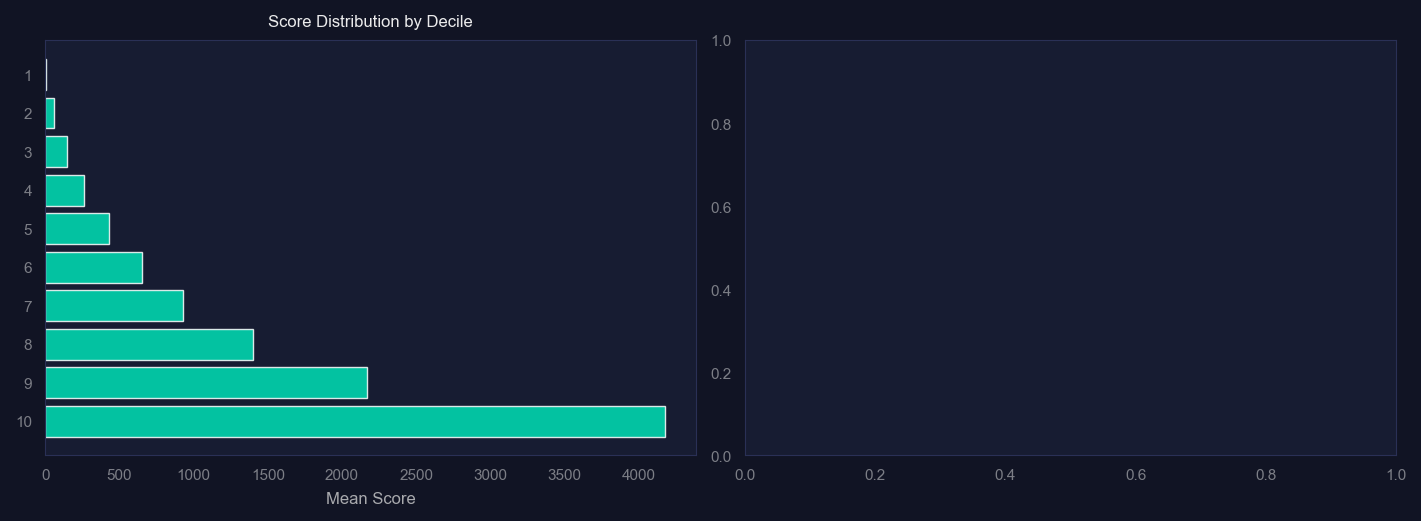

In [23]:
pipe_inc = g_income.model.build_scoring_pipeline(result=best_income)
pipe_inc.info()

train_ref = best_income.X_train.copy()
train_ref[best_income.target_col] = best_income.y_train.values
score_inc = pipe_inc.score_report(best_income.X_test, reference_df=train_ref, n_deciles=10)
score_inc.summary()
score_inc.plot()

drift_inc = g_income.prep.variate_shift(
    best_income.X_test,
    reference_df=best_income.X_train,
    features=best_income.feature_cols,
)
drift_inc.summary()
drift_inc.plot(top_n=12)
print("Drifted (PSI>0.2):", drift_inc.drifted_features())


## 8. 結論與作業對照

| 要求 | 作法 |
|------|------|
| 預測 total income & total expenses | 兩個 `GAMMA_DNA` regression session，各自 `g.train` + benchmark |
| Train / test 切分 | `test_size=0.2`, `random_state=42`；另以 5-fold CV 估計穩定性 |
| 多演算法比較 | Ridge / RF / GBM via `g.experiment.compare` |
| 評估指標 | **R²**、**RMSE**、**MAE**（`ModelResult.summary()`） |
| 僅用提供資料 | 所有特徵來自四份 CSV，無外部資料 |

**解讀**：`txn_count`、`active_days` 等交易強度特徵通常對兩個目標皆有解釋力；demographics（country、employment）提供增量 signal。若 R² 偏低，代表僅憑 profile + 摘要特徵難以完全還原加總金額 — 可再擴充 mcc / transaction_type pivot（作業允許的特徵工程方向）。


## 9. Pipeline Lineage


In [ ]:
display(g_income.stages)
g_income.visualize()
